# Actividad 9 – Corrección de perspectiva simple

**Objetivo**: usar 4 puntos manuales.

En esta actividad vamos a:
1. Cargar una imagen con un objeto rectangular
2. Definir 4 puntos manualmente (esquinas del objeto)
3. Aplicar transformación de perspectiva
4. Mostrar resultado frontal

## 1. Importar librerías necesarias

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen

Usa una imagen que contenga un objeto rectangular (documento, libro, tarjeta, etc.).

✓ Imagen cargada correctamente
  Dimensiones: 500 x 333 píxeles


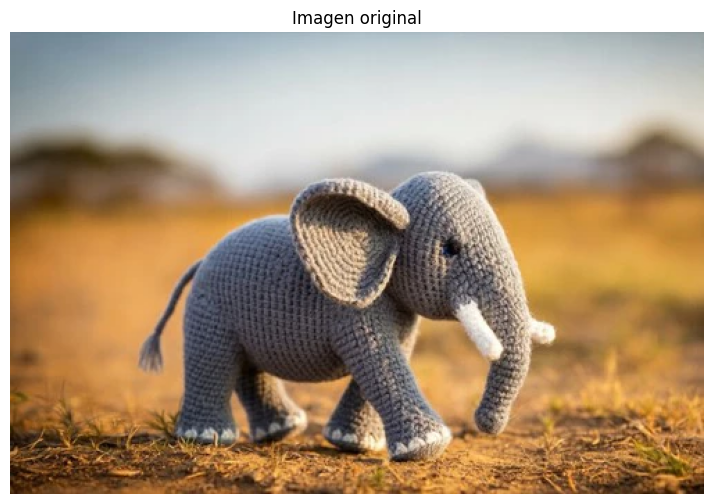

In [7]:
# Cargar la imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    
    # Obtener dimensiones
    alto, ancho = imagen.shape[:2]
    print(f"  Dimensiones: {ancho} x {alto} píxeles")
    
    # Mostrar la imagen original
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title('Imagen original')
    plt.show()

## 3. Definir 4 puntos manualmente

Define las coordenadas de las 4 esquinas del objeto rectangular en la imagen (en orden: superior izquierda, superior derecha, inferior derecha, inferior izquierda).

✓ Puntos definidos
Puntos origen (perspectiva):
  Superior izq: (100, 150)
  Superior der: (400, 100)
  Inferior der: (450, 200)
  Inferior izq: (80, 250)

Dimensiones salida: 400 x 300 px


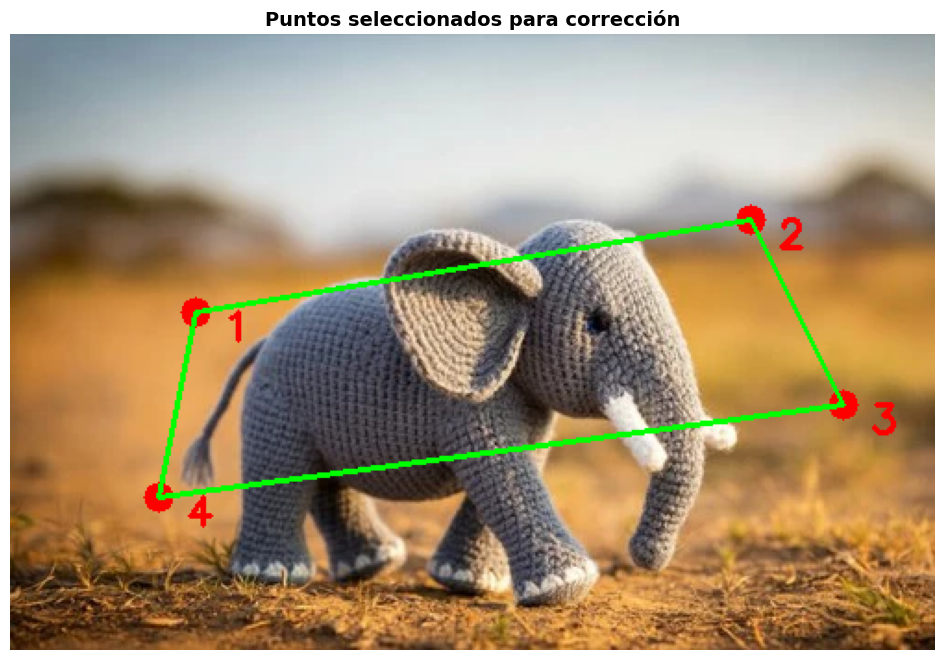

In [8]:
# Definir los 4 puntos del objeto en la imagen original (en perspectiva)
# Orden: superior izquierda, superior derecha, inferior derecha, inferior izquierda
# Ajusta estos valores según tu imagen
puntos_origen = np.float32([
    [100, 150],   # Superior izquierda
    [400, 100],   # Superior derecha
    [450, 200],   # Inferior derecha
    [80, 250]     # Inferior izquierda
])

# Definir las dimensiones del rectángulo de salida (vista frontal)
ancho_destino = 400
alto_destino = 300

# Puntos de destino (rectángulo frontal)
puntos_destino = np.float32([
    [0, 0],                              # Superior izquierda
    [ancho_destino, 0],                  # Superior derecha
    [ancho_destino, alto_destino],       # Inferior derecha
    [0, alto_destino]                    # Inferior izquierda
])

print("✓ Puntos definidos")
print(f"Puntos origen (perspectiva):")
for i, punto in enumerate(puntos_origen):
    etiquetas = ['Superior izq', 'Superior der', 'Inferior der', 'Inferior izq']
    print(f"  {etiquetas[i]}: ({punto[0]:.0f}, {punto[1]:.0f})")

print(f"\nDimensiones salida: {ancho_destino} x {alto_destino} px")

# Visualizar los puntos en la imagen original
imagen_con_puntos = imagen_rgb.copy()
for i, punto in enumerate(puntos_origen):
    cv2.circle(imagen_con_puntos, tuple(punto.astype(int)), 8, (255, 0, 0), -1)
    cv2.putText(imagen_con_puntos, str(i+1), tuple(punto.astype(int) + 15), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

# Dibujar líneas entre los puntos
puntos_int = puntos_origen.astype(int)
cv2.line(imagen_con_puntos, tuple(puntos_int[0]), tuple(puntos_int[1]), (0, 255, 0), 2)
cv2.line(imagen_con_puntos, tuple(puntos_int[1]), tuple(puntos_int[2]), (0, 255, 0), 2)
cv2.line(imagen_con_puntos, tuple(puntos_int[2]), tuple(puntos_int[3]), (0, 255, 0), 2)
cv2.line(imagen_con_puntos, tuple(puntos_int[3]), tuple(puntos_int[0]), (0, 255, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(imagen_con_puntos)
plt.title('Puntos seleccionados para corrección', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## 4. Aplicar transformación de perspectiva

Usamos `cv2.getPerspectiveTransform()` para obtener la matriz y `cv2.warpPerspective()` para aplicar la transformación.

In [9]:
# Obtener la matriz de transformación de perspectiva
matriz_perspectiva = cv2.getPerspectiveTransform(puntos_origen, puntos_destino)

# Aplicar la transformación
imagen_corregida = cv2.warpPerspective(imagen, matriz_perspectiva, (ancho_destino, alto_destino))

print("✓ Transformación de perspectiva aplicada")
print("\nMatriz de transformación:")
print(matriz_perspectiva)

# Convertir a RGB para visualización
imagen_corregida_rgb = cv2.cvtColor(imagen_corregida, cv2.COLOR_BGR2RGB)

✓ Transformación de perspectiva aplicada

Matriz de transformación:
[[ 2.58673887e+00  5.17347774e-01 -3.36276053e+02]
 [ 1.07449153e+00  6.44694918e+00 -1.07449153e+03]
 [ 1.20773251e-03  3.92292677e-03  1.00000000e+00]]


## 5. Mostrar resultado frontal

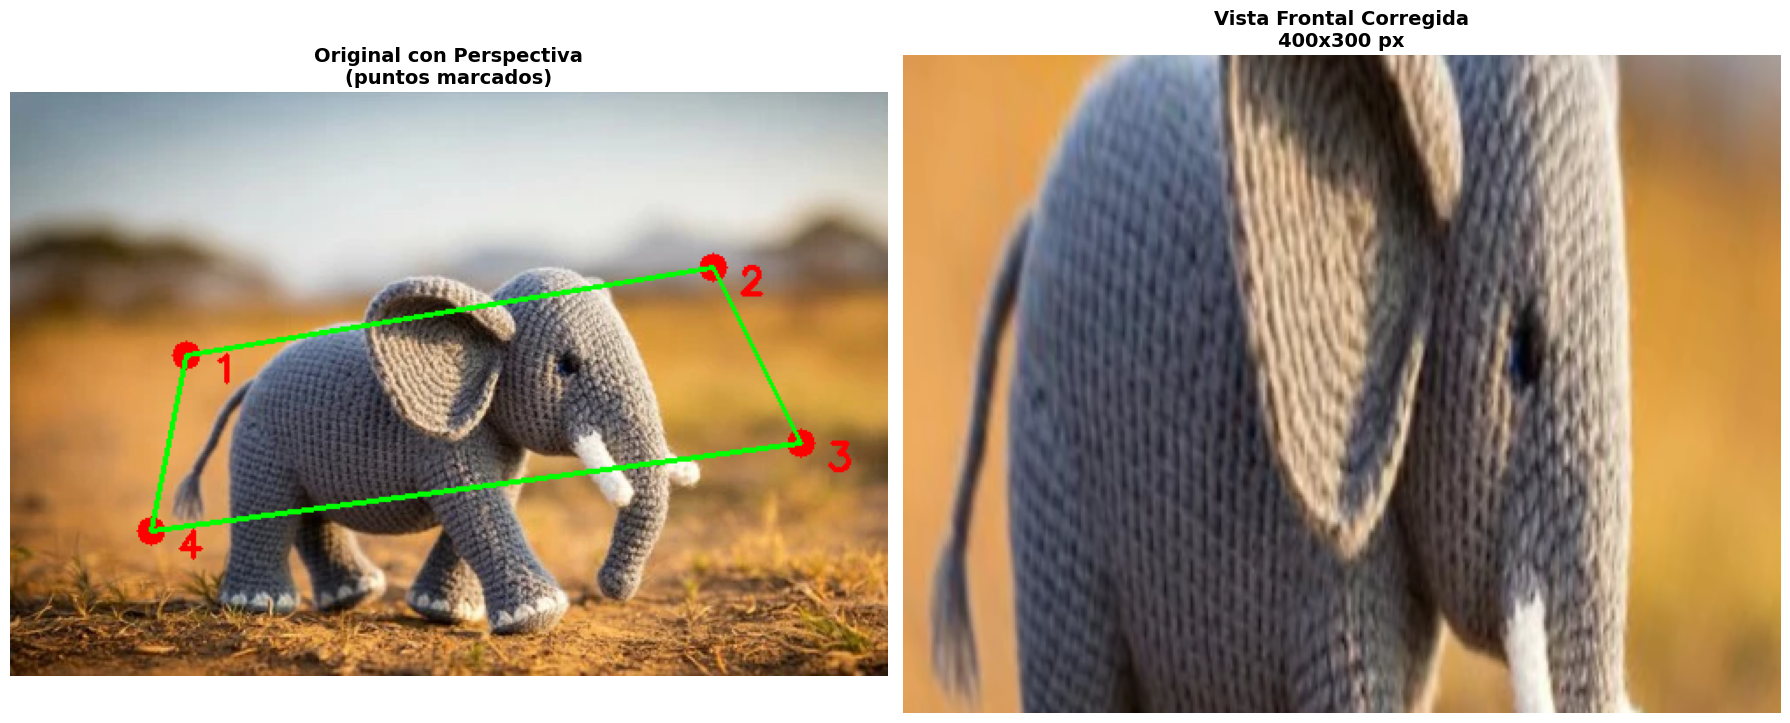


✓ Corrección de perspectiva completada
La imagen ahora muestra una vista frontal del objeto rectangular.


In [10]:
# Mostrar imagen original con puntos y resultado corregido
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Original con puntos marcados
axes[0].imshow(imagen_con_puntos)
axes[0].set_title('Original con Perspectiva\n(puntos marcados)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Imagen corregida (vista frontal)
axes[1].imshow(imagen_corregida_rgb)
axes[1].set_title(f'Vista Frontal Corregida\n{ancho_destino}x{alto_destino} px', 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Corrección de perspectiva completada")
print("La imagen ahora muestra una vista frontal del objeto rectangular.")